In [2]:
import os
import pandas as pd
import numpy as np
import librosa
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Định nghĩa path (dùng lại từ code của bạn)
DATASET_PATH = "D:/LA/LA"
PROTOCOLS_PATH = os.path.join(DATASET_PATH, "ASVspoof2019_LA_cm_protocols")
protocol_files = {
    "train": os.path.join(PROTOCOLS_PATH, "ASVspoof2019.LA.cm.train.trn.txt"),
    "dev": os.path.join(PROTOCOLS_PATH, "ASVspoof2019.LA.cm.dev.trl.txt"),
    "eval": os.path.join(PROTOCOLS_PATH, "ASVspoof2019.LA.cm.eval.trl.txt"),
}
audio_dirs = {
    "train": os.path.join(DATASET_PATH, "ASVspoof2019_LA_train/flac"),
    "dev": os.path.join(DATASET_PATH, "ASVspoof2019_LA_dev/flac"),
    "eval": os.path.join(DATASET_PATH, "ASVspoof2019_LA_eval/flac"),
}

# Hàm load protocol với nhãn là Spoof_Type
def load_protocol_data(protocol_path):
    df = pd.read_csv(protocol_path, sep=" ", header=None, 
                     names=["Speaker_ID", "File_ID", "-", "Spoof_Type", "Label"])
    # Giữ nguyên cột Spoof_Type làm nhãn đa lớp
    df = df[["File_ID", "Spoof_Type"]]
    return df

# Load dữ liệu
df_train = load_protocol_data(protocol_files["train"])
df_dev = load_protocol_data(protocol_files["dev"])
df_eval = load_protocol_data(protocol_files["eval"])

# Kiểm tra các loại tấn công
print("Train Spoof Types:", df_train["Spoof_Type"].value_counts())
print("Dev Spoof Types:", df_dev["Spoof_Type"].value_counts())
print("Eval Spoof Types:", df_eval["Spoof_Type"].value_counts())

Train Spoof Types: Spoof_Type
A01    3800
A02    3800
A03    3800
A04    3800
A05    3800
A06    3800
-      2580
Name: count, dtype: int64
Dev Spoof Types: Spoof_Type
A01    3716
A02    3716
A03    3716
A04    3716
A05    3716
A06    3716
-      2548
Name: count, dtype: int64
Eval Spoof Types: Spoof_Type
-      7355
A11    4914
A14    4914
A16    4914
A09    4914
A13    4914
A12    4914
A18    4914
A15    4914
A08    4914
A17    4914
A10    4914
A07    4914
A19    4914
Name: count, dtype: int64


In [3]:
import os
import pandas as pd
import numpy as np
import librosa
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from tqdm import tqdm
import joblib

# Đường dẫn để lưu đặc trưng
FEATURES_PATH = "D:/LA/features"
os.makedirs(FEATURES_PATH, exist_ok=True)

# Hàm trích xuất đặc trưng MFCC
def extract_mfcc(audio_path, n_mfcc=13, max_length=400):
    try:
        y, sr = librosa.load(audio_path, sr=16000)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        if mfcc.shape[1] < max_length:
            pad_width = max_length - mfcc.shape[1]
            mfcc = np.pad(mfcc, ((0, 0), (0, pad_width)), mode='constant')
        else:
            mfcc = mfcc[:, :max_length]
        return mfcc.flatten()
    except Exception as e:
        print(f"Error processing {audio_path}: {e}")
        return None

# Hàm trích xuất và lưu đặc trưng
def extract_and_save_features(df, audio_dir, split_name):
    X = []
    y = []
    feature_file = os.path.join(FEATURES_PATH, f"{split_name}_features.npz")
    
    # Nếu file đặc trưng đã tồn tại, load nó
    if os.path.exists(feature_file):
        print(f"Loading existing features for {split_name}...")
        data = np.load(feature_file)
        return data['X'], data['y']
    
    # Nếu chưa có, trích xuất và lưu
    print(f"Extracting features for {split_name}...")
    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"Processing {split_name}"):
        audio_path = os.path.join(audio_dir, f"{row['File_ID']}.flac")
        if os.path.exists(audio_path):
            features = extract_mfcc(audio_path)
            if features is not None:
                X.append(features)
                y.append(row['Spoof_Type'])
    
    X = np.array(X)
    y = np.array(y)
    np.savez(feature_file, X=X, y=y)
    print(f"Saved features to {feature_file}")
    return X, y

# Load protocol data
df_train = pd.read_csv(protocol_files["train"], sep=" ", header=None, 
                      names=["Speaker_ID", "File_ID", "-", "Spoof_Type", "Label"])[["File_ID", "Spoof_Type"]]
df_dev = pd.read_csv(protocol_files["dev"], sep=" ", header=None, 
                    names=["Speaker_ID", "File_ID", "-", "Spoof_Type", "Label"])[["File_ID", "Spoof_Type"]]
df_eval = pd.read_csv(protocol_files["eval"], sep=" ", header=None, 
                     names=["Speaker_ID", "File_ID", "-", "Spoof_Type", "Label"])[["File_ID", "Spoof_Type"]]

# Trích xuất và lưu đặc trưng
X_train, y_train = extract_and_save_features(df_train, audio_dirs["train"], "train")
X_dev, y_dev = extract_and_save_features(df_dev, audio_dirs["dev"], "dev")
X_eval, y_eval = extract_and_save_features(df_eval, audio_dirs["eval"], "eval")

# Chuẩn hóa đặc trưng
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_dev_scaled = scaler.transform(X_dev)
X_eval_scaled = scaler.transform(X_eval)

# Lưu scaler
joblib.dump(scaler, os.path.join(FEATURES_PATH, "scaler.pkl"))


Extracting features for train...


Processing train: 100%|██████████| 25380/25380 [06:59<00:00, 60.54it/s]


Saved features to D:/LA/features\train_features.npz
Extracting features for dev...


Processing dev: 100%|██████████| 24844/24844 [07:13<00:00, 57.29it/s]


Saved features to D:/LA/features\dev_features.npz
Extracting features for eval...


Processing eval: 100%|██████████| 71237/71237 [25:28<00:00, 46.60it/s]  


Saved features to D:/LA/features\eval_features.npz


['D:/LA/features\\scaler.pkl']

***1. MÔ HÌNH SVM***

Training SVM model...

Results for Development:
Overall Accuracy: 0.9224
Weighted F1-score: 0.9201

Classification Report:
              precision    recall  f1-score   support

           -       0.95      0.63      0.76      2548
         A01       0.94      0.93      0.94      3716
         A02       0.97      0.95      0.96      3716
         A03       0.91      1.00      0.95      3716
         A04       0.96      0.90      0.93      3716
         A05       0.98      0.99      0.98      3716
         A06       0.79      0.98      0.88      3716

    accuracy                           0.92     24844
   macro avg       0.93      0.91      0.91     24844
weighted avg       0.93      0.92      0.92     24844



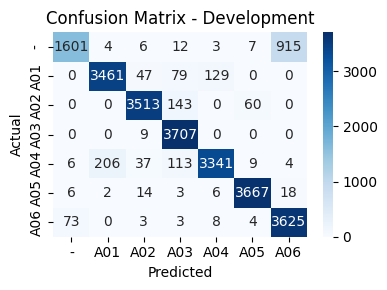


Per-class Accuracy:
 - -: 0.6283
 - A01: 0.9314
 - A02: 0.9454
 - A03: 0.9976
 - A04: 0.8991
 - A05: 0.9868
 - A06: 0.9755

Per-class AUC:
 - -: 0.9749
 - A01: 0.9973
 - A02: 0.9990
 - A03: 0.9996
 - A04: 0.9969
 - A05: 0.9994
 - A06: 0.9911

Final Results Summary:
Dev - Accuracy: 0.9224 | F1-score: 0.9201


In [1]:
import os
import numpy as np
import joblib
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Đường dẫn
FEATURES_PATH = "D:/LA/features"

# Load đặc trưng đã lưu
def load_features(split_name):
    file_path = os.path.join(FEATURES_PATH, f"{split_name}_features.npz")
    data = np.load(file_path)
    return data['X'], data['y']

# Hàm đánh giá mô hình
def evaluate_model(model, X, y, le, dataset_name):
    y_true = le.transform(y)
    y_pred = model.predict(X)
    y_pred_enc = le.transform(y_pred)
    y_proba = model.predict_proba(X)
    
    # Accuracy & F1
    acc = accuracy_score(y_true, y_pred_enc)
    f1 = f1_score(y_true, y_pred_enc, average='weighted')
    
    print(f"\nResults for {dataset_name}:")
    print(f"Overall Accuracy: {acc:.4f}")
    print(f"Weighted F1-score: {f1:.4f}")

    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred_enc, target_names=le.classes_))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred_enc)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'Confusion Matrix - {dataset_name}')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    # Accuracy per class
    print("\nPer-class Accuracy:")
    class_accs = cm.diagonal() / cm.sum(axis=1)
    for i, class_name in enumerate(le.classes_):
        print(f" - {class_name}: {class_accs[i]:.4f}")

    # AUC per class
    try:
        y_true_bin = label_binarize(y_true, classes=np.arange(len(le.classes_)))
        auc_scores = roc_auc_score(y_true_bin, y_proba, average=None, multi_class='ovr')
        print("\nPer-class AUC:")
        for i, class_name in enumerate(le.classes_):
            print(f" - {class_name}: {auc_scores[i]:.4f}")
    except Exception as e:
        print("\nCould not compute AUC:", e)
    
    return acc, f1

# Load dữ liệu
X_train, y_train = load_features("train")
X_dev, y_dev = load_features("dev")

# Encode nhãn
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_dev_enc = le.transform(y_dev)

# Chuẩn hóa
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_dev_scaled = scaler.transform(X_dev)

# Huấn luyện mô hình SVM
print("Training SVM model...")
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)

# Đánh giá
dev_acc, dev_f1 = evaluate_model(svm_model, X_dev_scaled, y_dev, le, "Development")

# Lưu model
joblib.dump(svm_model, os.path.join(FEATURES_PATH, "svm_spoof_type_detector.pkl"))

print("\nFinal Results Summary:")
print(f"Dev - Accuracy: {dev_acc:.4f} | F1-score: {dev_f1:.4f}")


***RANDOM FOREST***

In [2]:
import os
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc, f1_score, roc_auc_score
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize

# Đường dẫn đến thư mục đặc trưng
FEATURES_PATH = "D:/LA/features"

# Load đặc trưng đã được trích xuất
print("Loading features...")
train_data = np.load(os.path.join(FEATURES_PATH, "train_features.npz"))
dev_data = np.load(os.path.join(FEATURES_PATH, "dev_features.npz"))

X_train, y_train = train_data['X'], train_data['y']
X_dev, y_dev = dev_data['X'], dev_data['y']

# Load scaler đã lưu
scaler = joblib.load(os.path.join(FEATURES_PATH, "scaler.pkl"))

# Áp dụng scaler nếu chưa áp dụng
X_train_scaled = X_train if X_train.mean() < 1e-5 else scaler.transform(X_train)
X_dev_scaled = X_dev if X_dev.mean() < 1e-5 else scaler.transform(X_dev)

# Huấn luyện mô hình Random Forest
print("\nTraining Random Forest model...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42,
    class_weight='balanced'
)

# Huấn luyện mô hình trên tập train
rf_model.fit(X_train_scaled, y_train)

# Lưu mô hình
rf_model_path = os.path.join(FEATURES_PATH, "random_forest_model.pkl")
joblib.dump(rf_model, rf_model_path)
print(f"Random Forest model saved to {rf_model_path}")

# Dự đoán trên tập dev
y_dev_pred = rf_model.predict(X_dev_scaled)
y_dev_pred_proba = rf_model.predict_proba(X_dev_scaled)

# Lấy danh sách các loại tấn công duy nhất
unique_attacks = np.unique(y_dev)
n_classes = len(unique_attacks)

# Tạo ma trận nhầm lẫn
conf_matrix = confusion_matrix(y_dev, y_dev_pred)

# Vẽ confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
           xticklabels=unique_attacks, yticklabels=unique_attacks)
plt.title('Confusion Matrix - Dev Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig(os.path.join(FEATURES_PATH, 'rf_confusion_matrix_dev.png'))
plt.close()

# In confusion matrix dưới dạng văn bản
print("\nConfusion Matrix:")
print(conf_matrix)

# Tính toán và in ra metrics cho từng loại tấn công
print("\nMetrics by attack type (Dev Set):")
print("Attack Type\tAccuracy\tAUC\t\tF1-Score")
print("-" * 60)

# Binarize các nhãn để tính AUC (One-vs-Rest)
y_dev_bin = label_binarize(y_dev, classes=unique_attacks)

# Tính AUC cho từng lớp
auc_scores = []
for i, attack in enumerate(unique_attacks):
    # Lọc các mẫu thuộc loại tấn công này
    indices = y_dev == attack
    
    # Accuracy cho loại tấn công cụ thể
    attack_accuracy = accuracy_score(y_dev[indices], y_dev_pred[indices])
    
    # F1-score cho loại tấn công cụ thể (binary mode)
    f1 = f1_score((y_dev == attack).astype(int), (y_dev_pred == attack).astype(int))
    
    # AUC cho loại tấn công cụ thể
    try:
        # Xác suất dự đoán cho lớp này
        y_proba_class = y_dev_pred_proba[:, i]
        auc_score = roc_auc_score(y_dev_bin[:, i], y_proba_class)
        auc_scores.append(auc_score)
    except:
        auc_score = float('nan')
    
    count = np.sum(indices)
    print(f"{attack}\t\t{attack_accuracy:.4f}\t\t{auc_score:.4f}\t\t{f1:.4f}\t({count} samples)")

# Tính và in ra metrics tổng hợp
print("\nOverall Metrics:")
overall_accuracy = accuracy_score(y_dev, y_dev_pred)
overall_f1 = f1_score(y_dev, y_dev_pred, average='weighted')

# Tính AUC macro average 
overall_auc = np.mean(auc_scores)

print(f"Accuracy: {overall_accuracy:.4f}")
print(f"Macro-average AUC: {overall_auc:.4f}")
print(f"Weighted F1-score: {overall_f1:.4f}")

# In classification report
print("\nClassification Report:")
print(classification_report(y_dev, y_dev_pred))

Loading features...

Training Random Forest model...
Random Forest model saved to D:/LA/features\random_forest_model.pkl

Confusion Matrix:
[[1332    0    0    0    6   13 1197]
 [   0 3649    0    0   67    0    0]
 [   0    0 3237    0    0  479    0]
 [   0    0    0 3716    0    0    0]
 [   7   50    0    0 3652    4    3]
 [  10    0    0    0    9 3697    0]
 [  52    0    0    0    3    6 3655]]

Metrics by attack type (Dev Set):
Attack Type	Accuracy	AUC		F1-Score
------------------------------------------------------------
-		0.5228		0.9878		0.6746	(2548 samples)
A01		0.9820		0.9998		0.9842	(3716 samples)
A02		0.8711		1.0000		0.9311	(3716 samples)
A03		1.0000		1.0000		1.0000	(3716 samples)
A04		0.9828		0.9992		0.9800	(3716 samples)
A05		0.9949		0.9991		0.9342	(3716 samples)
A06		0.9836		0.9920		0.8529	(3716 samples)

Overall Metrics:
Accuracy: 0.9233
Macro-average AUC: 0.9968
Weighted F1-score: 0.9191

Classification Report:
              precision    recall  f1-score   suppor

***3.MÔ HÌNH LCNN***

 Training...
Epoch 1/100 - Loss: 0.3077
Epoch 2/100 - Loss: 0.0744
Epoch 3/100 - Loss: 0.0528
Epoch 4/100 - Loss: 0.0481
Epoch 5/100 - Loss: 0.0405
Epoch 6/100 - Loss: 0.0298
Epoch 7/100 - Loss: 0.0313
Epoch 8/100 - Loss: 0.0230
Epoch 9/100 - Loss: 0.0253
Epoch 10/100 - Loss: 0.0180
Epoch 11/100 - Loss: 0.0275
Epoch 12/100 - Loss: 0.0190
Epoch 13/100 - Loss: 0.0141
Epoch 14/100 - Loss: 0.0320
Epoch 15/100 - Loss: 0.0211
Epoch 16/100 - Loss: 0.0207
Epoch 17/100 - Loss: 0.0169
Epoch 18/100 - Loss: 0.0212
Epoch 19/100 - Loss: 0.0151
Epoch 20/100 - Loss: 0.0236
Epoch 21/100 - Loss: 0.0235
Epoch 22/100 - Loss: 0.0170
Epoch 23/100 - Loss: 0.0133
Epoch 24/100 - Loss: 0.0119
Epoch 25/100 - Loss: 0.0203
Epoch 26/100 - Loss: 0.0174
Epoch 27/100 - Loss: 0.0131
Epoch 28/100 - Loss: 0.0178
Epoch 29/100 - Loss: 0.0194
Epoch 30/100 - Loss: 0.0140
Epoch 31/100 - Loss: 0.0224
Epoch 32/100 - Loss: 0.0143
Epoch 33/100 - Loss: 0.0264
Epoch 34/100 - Loss: 0.0127
Epoch 35/100 - Loss: 0.0137
Epoch 36/100 - L

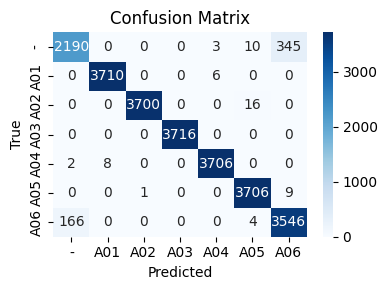


📋 Classification Report:
              precision    recall  f1-score   support

           -       0.93      0.86      0.89      2548
         A01       1.00      1.00      1.00      3716
         A02       1.00      1.00      1.00      3716
         A03       1.00      1.00      1.00      3716
         A04       1.00      1.00      1.00      3716
         A05       0.99      1.00      0.99      3716
         A06       0.91      0.95      0.93      3716

    accuracy                           0.98     24844
   macro avg       0.98      0.97      0.97     24844
weighted avg       0.98      0.98      0.98     24844



['D:/LA/features\\LCNN.pkl']

In [2]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_auc_score, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import dump


# ----- Load features -----
FEATURES_PATH = "D:/LA/features"
train_data = np.load(f"{FEATURES_PATH}/train_features.npz")
dev_data = np.load(f"{FEATURES_PATH}/dev_features.npz")

X_train, y_train = train_data['X'], train_data['y']
X_dev, y_dev = dev_data['X'], dev_data['y']

# Encode labels
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_dev_enc = label_encoder.transform(y_dev)
n_classes = len(label_encoder.classes_)
class_names = label_encoder.classes_

# Reshape MFCCs to (batch, 1, 13, 400)
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).reshape(-1, 1, 13, 400)
X_dev_tensor = torch.tensor(X_dev, dtype=torch.float32).reshape(-1, 1, 13, 400)
y_train_tensor = torch.tensor(y_train_enc, dtype=torch.long)
y_dev_tensor = torch.tensor(y_dev_enc, dtype=torch.long)

# ----- Dataset & DataLoader -----
class MFCCDataset(Dataset):
    def __init__(self, X, y):
        self.X, self.y = X, y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(MFCCDataset(X_train_tensor, y_train_tensor), batch_size=32, shuffle=True)
dev_loader = DataLoader(MFCCDataset(X_dev_tensor, y_dev_tensor), batch_size=32)

# ----- LCNN Model -----
class LCNN(nn.Module):
    def __init__(self, input_shape=(1, 13, 400), num_classes=5):
        super(LCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.dropout = nn.Dropout(0.3)

        dummy = torch.zeros(1, *input_shape)
        out = self._forward_features(dummy)
        flatten_size = out.view(1, -1).shape[1]

        self.fc1 = nn.Linear(flatten_size, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def _forward_features(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        return x

    def forward(self, x):
        x = self._forward_features(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        return self.fc2(x)

# ----- Training -----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LCNN(num_classes=n_classes).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

print(" Training...")
for epoch in range(100):
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/100 - Loss: {total_loss/len(train_loader):.4f}")

# ----- Evaluation -----
model.eval()
all_preds, all_probs, all_labels = [], [], []

with torch.no_grad():
    for X_batch, y_batch in dev_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        probs = F.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(y_batch.numpy())

# Metrics
y_true = np.array(all_labels)
y_pred = np.array(all_preds)
y_prob = np.array(all_probs)

acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average="macro")
auc_per_class = []

print("\n Evaluation Metrics:")
print(f" Accuracy      : {acc:.4f}")
print(f" F1-score (avg): {f1:.4f}")

# AUC từng lớp
print("\n AUC per class:")
for i in range(n_classes):
    try:
        auc = roc_auc_score((y_true == i).astype(int), y_prob[:, i])
        auc_per_class.append(auc)
        print(f"   - {class_names[i]}: {auc:.4f}")
    except:
        print(f"   - {class_names[i]}: Không thể tính AUC")

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# Classification report (chi tiết precision/recall cho từng lớp)
print("\n📋 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Lưu LCNN model
dump(model, os.path.join(FEATURES_PATH, "LCNN.pkl")) 

***4.MÔ HÌNH BILSTM***

Loading training and development features...
Loading features from D:/LA/features\train_features.npz
Loading features from D:/LA/features\dev_features.npz
Training set: (25380, 5200), (25380,)
Development set: (24844, 5200), (24844,)
Loading and applying scaler...
Encoding labels...
Number of classes: 7
Classes: ['-' 'A01' 'A02' 'A03' 'A04' 'A05' 'A06']
Reshaped training set: (25380, 400, 13)
Reshaped development set: (24844, 400, 13)
Building BiLSTM model...


C:\Users\VanKhanh\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 400, 256)       │       145,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 400, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 318,471 (1.21 MB)

...

794/794 ━━━━━━━━━━━━━━━━━━━━ 318s 400ms/step - accuracy: 0.9722 - loss: 0.0805 - val_accuracy: 0.9519 - val_loss: 0.1510
Epoch 16/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - accuracy: 0.9769 - loss: 0.0659
Epoch 16: val_accuracy did not improve from 0.95186
794/794 ━━━━━━━━━━━━━━━━━━━━ 316s 398ms/step - accuracy: 0.9769 - loss: 0.0659 - val_accuracy: 0.9447 - val_loss: 0.1680
Epoch 17/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step - accuracy: 0.9786 - loss: 0.0613
Epoch 17: val_accuracy did not improve from 0.95186
794/794 ━━━━━━━━━━━━━━━━━━━━ 317s 400ms/step - accuracy: 0.9786 - loss: 0.0613 - val_accuracy: 0.9411 - val_loss: 0.2026
Epoch 18/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 0.9810 - loss: 0.0577
Epoch 18: val_accuracy did not improve from 0.95186
794/794 ━━━━━━━━━━━━━━━━━━━━ 314s 395ms/step - accuracy: 0.9810 - loss: 0.0577 - val_accuracy: 0.9496 - val_loss: 0.1638
Epoch 19/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.9813 - loss: 0.0547


794/794 ━━━━━━━━━━━━━━━━━━━━ 652s 822ms/step - accuracy: 0.9829 - loss: 0.0498 - val_accuracy: 0.9580 - val_loss: 0.1418
Epoch 24/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 0s 611ms/step - accuracy: 0.9861 - loss: 0.0451
Epoch 24: val_accuracy did not improve from 0.95798
794/794 ━━━━━━━━━━━━━━━━━━━━ 687s 866ms/step - accuracy: 0.9861 - loss: 0.0451 - val_accuracy: 0.9523 - val_loss: 0.1603
Epoch 25/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 0s 613ms/step - accuracy: 0.9881 - loss: 0.0343
Epoch 25: val_accuracy did not improve from 0.95798
794/794 ━━━━━━━━━━━━━━━━━━━━ 651s 821ms/step - accuracy: 0.9881 - loss: 0.0343 - val_accuracy: 0.9453 - val_loss: 0.2273
Epoch 26/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 0s 612ms/step - accuracy: 0.9865 - loss: 0.0392
Epoch 26: val_accuracy did not improve from 0.95798
794/794 ━━━━━━━━━━━━━━━━━━━━ 638s 804ms/step - accuracy: 0.9865 - loss: 0.0392 - val_accuracy: 0.9512 - val_loss: 0.1875
Epoch 27/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 0s 606ms/step - accuracy: 0.9907 - loss: 0.0314


794/794 ━━━━━━━━━━━━━━━━━━━━ 314s 395ms/step - accuracy: 0.9945 - loss: 0.0168 - val_accuracy: 0.9588 - val_loss: 0.1981
Epoch 34/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step - accuracy: 0.9942 - loss: 0.0180
Epoch 34: val_accuracy did not improve from 0.95878
794/794 ━━━━━━━━━━━━━━━━━━━━ 319s 401ms/step - accuracy: 0.9942 - loss: 0.0180 - val_accuracy: 0.9449 - val_loss: 0.2438
Epoch 35/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - accuracy: 0.9930 - loss: 0.0219
Epoch 35: val_accuracy did not improve from 0.95878
794/794 ━━━━━━━━━━━━━━━━━━━━ 322s 406ms/step - accuracy: 0.9930 - loss: 0.0219 - val_accuracy: 0.9463 - val_loss: 0.2385
Epoch 36/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - accuracy: 0.9918 - loss: 0.0257
Epoch 36: val_accuracy did not improve from 0.95878
794/794 ━━━━━━━━━━━━━━━━━━━━ 323s 407ms/step - accuracy: 0.9918 - loss: 0.0257 - val_accuracy: 0.9579 - val_loss: 0.1951
Epoch 37/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step - accuracy: 0.9953 - loss: 0.0144


794/794 ━━━━━━━━━━━━━━━━━━━━ 317s 399ms/step - accuracy: 0.9935 - loss: 0.0198 - val_accuracy: 0.9607 - val_loss: 0.1753
Epoch 40/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 0.9960 - loss: 0.0129
Epoch 40: val_accuracy did not improve from 0.96067
794/794 ━━━━━━━━━━━━━━━━━━━━ 315s 397ms/step - accuracy: 0.9960 - loss: 0.0129 - val_accuracy: 0.9511 - val_loss: 0.2451
Epoch 41/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 0.9941 - loss: 0.0174
Epoch 41: val_accuracy did not improve from 0.96067
794/794 ━━━━━━━━━━━━━━━━━━━━ 316s 398ms/step - accuracy: 0.9941 - loss: 0.0174 - val_accuracy: 0.9537 - val_loss: 0.2906
Epoch 42/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - accuracy: 0.9950 - loss: 0.0179
Epoch 42: val_accuracy did not improve from 0.96067
794/794 ━━━━━━━━━━━━━━━━━━━━ 316s 399ms/step - accuracy: 0.9950 - loss: 0.0179 - val_accuracy: 0.9520 - val_loss: 0.3211
Epoch 43/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - accuracy: 0.9964 - loss: 0.0122



=== EVALUATING MODEL ON DEVELOPMENT SET ===
777/777 ━━━━━━━━━━━━━━━━━━━━ 86s 110ms/step

1. Overall Accuracy: 0.9607
2. Overall AUC (One vs Rest): 0.9974
   Overall AUC (One vs One): 0.9974
3. Overall F1-score (Macro): 0.9532
   Overall F1-score (Weighted): 0.9597
4. Overall Precision (Macro): 0.9619
   Overall Recall (Macro): 0.9499

5. Classification Report:
              precision    recall  f1-score   support

           -       0.94      0.72      0.82      2548
         A01       0.99      0.99      0.99      3716
         A02       0.98      0.99      0.99      3716
         A03       1.00      1.00      1.00      3716
         A04       0.99      0.99      0.99      3716
         A05       0.99      0.98      0.98      3716
         A06       0.84      0.97      0.90      3716

    accuracy                           0.96     24844
   macro avg       0.96      0.95      0.95     24844
weighted avg       0.96      0.96      0.96     24844


6. Confusion Matrix:
[[1839    0    0 

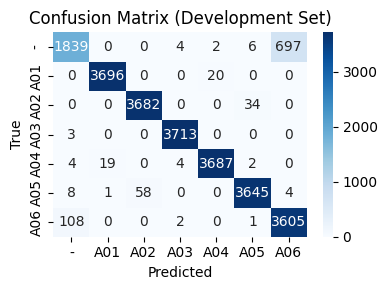

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM, Bidirectional
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from sklearn.metrics import (classification_report, confusion_matrix, 
                           accuracy_score, roc_auc_score, f1_score, 
                           precision_score, recall_score)
import seaborn as sns
import joblib
import pandas as pd

# Đường dẫn lưu mô hình
MODEL_PATH = "D:/LA/models"
os.makedirs(MODEL_PATH, exist_ok=True)

# Đường dẫn đặc trưng
FEATURES_PATH = "D:/LA/features"

# Load dữ liệu đặc trưng
def load_features(split_name):
    feature_file = os.path.join(FEATURES_PATH, f"{split_name}_features.npz")
    print(f"Loading features from {feature_file}")
    data = np.load(feature_file)
    return data['X'], data['y']

print("Loading training and development features...")
# Load chỉ tập train và dev
X_train, y_train = load_features("train")
X_dev, y_dev = load_features("dev")

print(f"Training set: {X_train.shape}, {y_train.shape}")
print(f"Development set: {X_dev.shape}, {y_dev.shape}")

# Load scaler
print("Loading and applying scaler...")
scaler = joblib.load(os.path.join(FEATURES_PATH, "scaler.pkl"))

# Chuẩn hóa dữ liệu
X_train_scaled = scaler.transform(X_train)
X_dev_scaled = scaler.transform(X_dev)

# Encode nhãn
print("Encoding labels...")
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_dev_encoded = label_encoder.transform(y_dev)

# Lưu label encoder
joblib.dump(label_encoder, os.path.join(MODEL_PATH, "label_encoder.pkl"))

# Đếm số lượng lớp
num_classes = len(np.unique(y_train_encoded))
print(f"Number of classes: {num_classes}")
print(f"Classes: {label_encoder.classes_}")

# Chuyển nhãn thành one-hot encoding
y_train_categorical = to_categorical(y_train_encoded, num_classes=num_classes)
y_dev_categorical = to_categorical(y_dev_encoded, num_classes=num_classes)

# Reshape dữ liệu cho LSTM
# Giả sử mỗi MFCC có 13 coefficients và max_length=400
n_mfcc = 13
max_length = 400
X_train_reshaped = X_train_scaled.reshape(X_train_scaled.shape[0], max_length, n_mfcc)
X_dev_reshaped = X_dev_scaled.reshape(X_dev_scaled.shape[0], max_length, n_mfcc)

print(f"Reshaped training set: {X_train_reshaped.shape}")
print(f"Reshaped development set: {X_dev_reshaped.shape}")

# Xây dựng mô hình BiLSTM
def build_bilstm_model():
    model = Sequential()
    
    # BiLSTM layers
    model.add(Bidirectional(LSTM(128, return_sequences=True), input_shape=(max_length, n_mfcc)))
    model.add(Dropout(0.3))
    model.add(Bidirectional(LSTM(64)))
    model.add(Dropout(0.3))
    
    # Dense layers
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(num_classes, activation='softmax'))
    
    # Compile
    model.compile(loss='categorical_crossentropy', 
                  optimizer='adam', 
                  metrics=['accuracy'])
    return model

# Khởi tạo mô hình
print("Building BiLSTM model...")
model = build_bilstm_model()
model.summary()

# Callbacks
checkpoint = ModelCheckpoint(
    os.path.join(MODEL_PATH, 'bilstm_best_model.h5'),
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Huấn luyện mô hình
print("Training model...")
history = model.fit(
    X_train_reshaped,
    y_train_categorical,
    batch_size=32,
    epochs=100,
    validation_data=(X_dev_reshaped, y_dev_categorical),
    callbacks=[checkpoint, early_stopping],
    verbose=1
)

# Lưu model cuối cùng
model.save(os.path.join(MODEL_PATH, 'bilstm_final_model.h5'))

# Đánh giá chi tiết mô hình trên tập dev
print("\n=== EVALUATING MODEL ON DEVELOPMENT SET ===")

# Dự đoán trên tập dev
y_dev_pred_prob = model.predict(X_dev_reshaped)
y_dev_pred_classes = np.argmax(y_dev_pred_prob, axis=1)

# Chuyển đổi nhãn dự đoán về tên lớp gốc
y_dev_pred_names = label_encoder.inverse_transform(y_dev_pred_classes)
y_dev_true_names = label_encoder.inverse_transform(y_dev_encoded)

# ----- Tính toán các chỉ số hiệu suất tổng thể -----

# 1. Accuracy
acc = accuracy_score(y_dev_encoded, y_dev_pred_classes)
print(f"\n1. Overall Accuracy: {acc:.4f}")

# 2. Multi-class AUC (One vs Rest)
try:
    # AUC cho multiple classes - one vs rest
    auc_ovr = roc_auc_score(y_dev_categorical, y_dev_pred_prob, multi_class='ovr')
    print(f"2. Overall AUC (One vs Rest): {auc_ovr:.4f}")
    
    # AUC cho multiple classes - one vs one
    auc_ovo = roc_auc_score(y_dev_categorical, y_dev_pred_prob, multi_class='ovo')
    print(f"   Overall AUC (One vs One): {auc_ovo:.4f}")
except Exception as e:
    print(f"Không thể tính AUC: {e}")

# 3. F1-score tổng thể
# Macro - tính trung bình cho mỗi lớp, không phụ thuộc số lượng mẫu
f1_macro = f1_score(y_dev_encoded, y_dev_pred_classes, average='macro')
# Weighted - trung bình có trọng số theo số lượng mẫu
f1_weighted = f1_score(y_dev_encoded, y_dev_pred_classes, average='weighted')
print(f"3. Overall F1-score (Macro): {f1_macro:.4f}")
print(f"   Overall F1-score (Weighted): {f1_weighted:.4f}")

# 4. Precision và Recall tổng thể
precision_macro = precision_score(y_dev_encoded, y_dev_pred_classes, average='macro')
recall_macro = recall_score(y_dev_encoded, y_dev_pred_classes, average='macro')
print(f"4. Overall Precision (Macro): {precision_macro:.4f}")
print(f"   Overall Recall (Macro): {recall_macro:.4f}")

# 5. In báo cáo phân loại chi tiết
print("\n5. Classification Report:")
print(classification_report(y_dev_true_names, y_dev_pred_names))

# 6. Confusion Matrix
cm = confusion_matrix(y_dev_encoded, y_dev_pred_classes)
print("\n6. Confusion Matrix:")
print(cm)

# ----- Tạo dataframe lưu các chỉ số cho mỗi loại tấn công -----
class_report = classification_report(y_dev_true_names, y_dev_pred_names, output_dict=True)

# Khởi tạo dữ liệu cho DataFrame
attack_types = []
precisions = []
recalls = []
f1_scores = []
supports = []
aucs = []

# In kết quả chi tiết cho từng loại tấn công
print("\n=== DETAILED METRICS FOR EACH ATTACK TYPE ===")
print("-" * 70)
print(f"{'Attack Type':<20} {'Precision':<10} {'Recall':<10} {'F1-Score':<10} {'AUC':<10} {'Support':<10}")
print("-" * 70)

# Thu thập các chỉ số cho mỗi lớp
for class_name in sorted(label_encoder.classes_):
    if class_name in class_report:
        metrics = class_report[class_name]
        
        # Calculate AUC for this class
        try:
            # Get index of this class
            class_idx = np.where(label_encoder.classes_ == class_name)[0][0]
            # Calculate AUC for this class (one vs rest)
            y_true_binary = (y_dev_encoded == class_idx).astype(int)
            y_score = y_dev_pred_prob[:, class_idx]
            auc = roc_auc_score(y_true_binary, y_score)
        except Exception as e:
            auc = float('nan')
            print(f"Cannot calculate AUC for {class_name}: {e}")
        
        # Print metrics for this class
        print(f"{class_name:<20} {metrics['precision']:.4f}     {metrics['recall']:.4f}     "
              f"{metrics['f1-score']:.4f}     {auc:.4f}     {int(metrics['support']):d}")
        
        # Add to lists for DataFrame
        attack_types.append(class_name)
        precisions.append(metrics['precision'])
        recalls.append(metrics['recall'])
        f1_scores.append(metrics['f1-score'])
        supports.append(int(metrics['support']))
        aucs.append(auc)

print("-" * 70)

# Tạo DataFrame
per_class_metrics_df = pd.DataFrame({
    'Attack_Type': attack_types,
    'Precision': precisions,
    'Recall': recalls,
    'F1_Score': f1_scores,
    'AUC': aucs,
    'Support': supports
})

# Lưu DataFrame vào CSV
per_class_metrics_path = os.path.join(MODEL_PATH, 'per_class_metrics.csv')
per_class_metrics_df.to_csv(per_class_metrics_path, index=False)
print(f"\nDetailed metrics for each attack type saved to: {per_class_metrics_path}")

# Tạo Confusion Matrix hình ảnh
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (Development Set)')
plt.tight_layout()
confusion_matrix_path = os.path.join(MODEL_PATH, 'confusion_matrix_dev.png')
plt.savefig(confusion_matrix_path)
print(f"Confusion matrix saved to: {confusion_matrix_path}")

# Lưu lại kết quả huấn luyện
np.save(os.path.join(MODEL_PATH, 'training_history.npy'), history.history)

print(f"\nTraining complete. Model and results saved to {MODEL_PATH}")
